# 01 - Trend Identification
Detect swing highs/lows, visualise on candlestick chart, and tune lookback per timeframe.

In [1]:
# Cell 1 - Imports, setup, data loading
%matplotlib inline

import sys
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Ensure project root is on the path (notebook runs from notebook/ subdir)
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.core.features import (
    compute_price_features, normalize_candles, detect_swings,
    compute_zigzag, detect_bos_choch_from_zigzag,
)
from src.adapters.local_data import load_ohlc_from_csv

# Lookback parameter per timeframe -- tune these for better pivot detection
LOOKBACK_CONFIG = {"1m": 5, "5m": 8, "15m": 10, "1H": 15, "4H": 20, "D": 20}

# Defaults (overridden by CSV filename when real data is present)
TIMEFRAME = '1H'
SYMBOL    = 'DEMO'

# Load data: real CSV if available, else generate synthetic
processed_dir = ROOT / 'data' / 'processed'
csv_files = sorted(processed_dir.glob('*.csv')) if processed_dir.exists() else []

if csv_files:
    csv_path = csv_files[0]
    candles  = load_ohlc_from_csv(csv_path)
    # Detect symbol and timeframe from filename: e.g. R_10_15m.csv -> R_10, 15m
    stem_parts = csv_path.stem.rsplit('_', 1)
    SYMBOL    = stem_parts[0] if len(stem_parts) == 2 else csv_path.stem
    TIMEFRAME = stem_parts[1] if len(stem_parts) == 2 else '1H'
    print(f'Loaded: {csv_path.name} | Timeframe: {TIMEFRAME} | Candles: {len(candles)}')
else:
    print('No CSV found -- generating 300-bar synthetic dataset')
    np.random.seed(42)
    n   = 300
    t   = np.linspace(0, 5 * np.pi, n)
    mid = (
        1000
        + 80  * np.sin(t * 0.6)
        + 40  * np.sin(t * 1.5)
        + 20  * np.sin(t * 3.0)
        + np.cumsum(np.random.randn(n) * 1.2)
    )
    vol    = 5 + 3 * np.abs(np.sin(t * 1.2))
    opens  = mid + np.random.randn(n) * vol * 0.35
    closes = mid + np.random.randn(n) * vol * 0.35
    highs  = np.maximum(opens, closes) + np.abs(np.random.randn(n)) * vol * 0.65
    lows   = np.minimum(opens, closes) - np.abs(np.random.randn(n)) * vol * 0.65
    base   = datetime(2024, 1, 1)
    rows   = [
        {
            'timestamp': (base + timedelta(hours=i)).isoformat(),
            'open':  float(opens[i]),
            'high':  float(highs[i]),
            'low':   float(lows[i]),
            'close': float(closes[i]),
        }
        for i in range(n)
    ]
    candles   = normalize_candles(rows)
    SYMBOL    = 'SYNTH'
    TIMEFRAME = '1H'
    print(f'Loaded: synthetic | Timeframe: {TIMEFRAME} | Candles: {len(candles)}')

print(f'First: {candles[0].timestamp}   Last: {candles[-1].timestamp}')


Loaded: R_10_15m.csv | Timeframe: 15m | Candles: 1000
First: 2026-02-11 13:45:00   Last: 2026-02-21 23:30:00


In [2]:
# Cell 2 - Feature computation and swing summary
features    = compute_price_features(candles, timeframe=TIMEFRAME)
swings      = features['structure_map']['swings']
swing_highs = features['structure_map']['swing_highs']
swing_lows  = features['structure_map']['swing_lows']

print(f'Total swings : {len(swings)}')
print(f'  Swing Highs: {len(swing_highs)}')
print(f'  Swing Lows : {len(swing_lows)}')
print()

if swings:
    header = f"{'idx':>5}  {'timestamp':<26}  {'type':<4}  {'price':>10}  {'strength':>8}"
    print(header)
    print('-' * len(header))
    for s in swings[:5]:
        ts = str(s.get('timestamp', ''))[:26]
        print(f"{s['index']:>5}  {ts:<26}  {s['type']:<4}  {s['price']:>10.4f}  {s['strength']:>8.3f}")
else:
    print('No swings detected -- try more candles or smaller lookback')


Total swings : 52
  Swing Highs: 26
  Swing Lows : 26

  idx  timestamp                   type       price  strength
-------------------------------------------------------------
    9  2026-02-16 21:00:00         SH     5179.8310     2.695
   12  2026-02-16 21:45:00         SL     5164.3810     2.089
   16  2026-02-16 22:45:00         SH     5173.6780     2.099
   26  2026-02-17 01:15:00         SL     5154.9940     2.285
   30  2026-02-17 02:15:00         SH     5166.3930     2.137


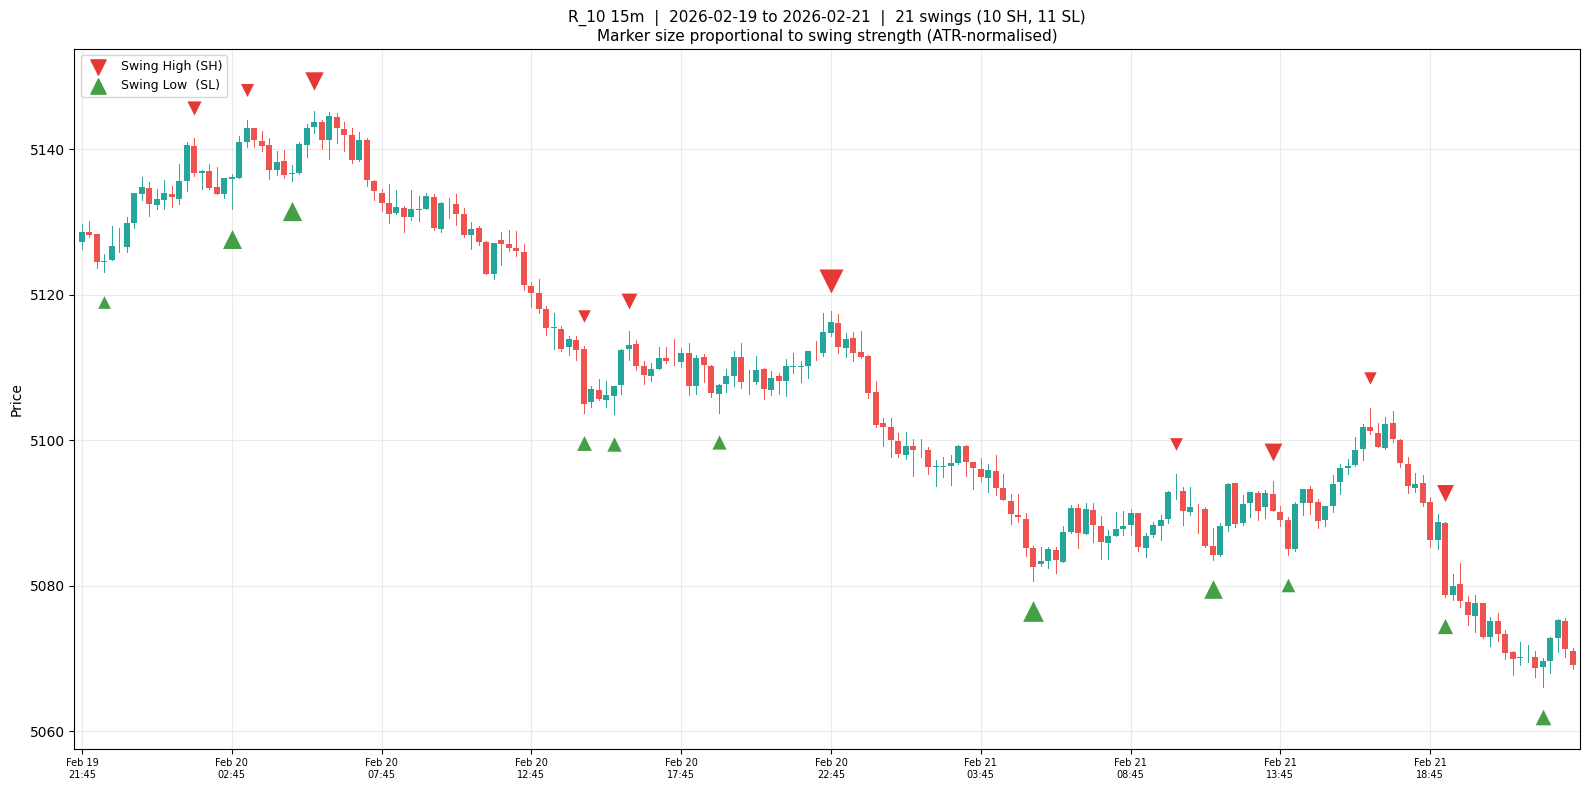

In [3]:
# Cell 3 - Candlestick chart with swing overlays
#
# Index-space note:
#   compute_price_features() truncates input to max_lookback=500 internally.
#   Swing indices are therefore relative to candles[-n_feat:], NOT to the
#   full candles list. We use features["meta"]["num_candles"] (n_feat) to
#   map swing indices into the display window correctly.

n_feat      = features["meta"]["num_candles"]   # candles actually used (<500)
feat_offset = len(candles) - n_feat             # candles dropped from front

WINDOW      = min(200, n_feat)
disp_offset = n_feat - WINDOW                   # start of display window

display_candles = candles[feat_offset:][-WINDOW:]
display_swings  = [
    {**s, 'di': s['index'] - disp_offset}
    for s in swings
    if 0 <= s['index'] - disp_offset < WINDOW
]

fig, ax = plt.subplots(figsize=(16, 8))

UP_COLOR   = '#26a69a'
DOWN_COLOR = '#ef5350'

for i, c in enumerate(display_candles):
    color   = UP_COLOR if c.close >= c.open else DOWN_COLOR
    body_lo = min(c.open, c.close)
    body_hi = max(c.open, c.close)
    body_h  = max(body_hi - body_lo, (c.high - c.low) * 0.01)

    ax.plot([i, i], [c.low, c.high], color=color, linewidth=0.7, zorder=1)
    ax.add_patch(Rectangle(
        (i - 0.4, body_lo), 0.8, body_h,
        facecolor=color, edgecolor=color, linewidth=0, zorder=2,
    ))

if display_swings:
    strengths = [s['strength'] for s in display_swings]
    s_min, s_max = min(strengths), max(strengths)
    s_range = max(s_max - s_min, 1e-6)

    for s in display_swings:
        di   = s['di']
        c    = display_candles[di]
        norm = (s['strength'] - s_min) / s_range
        size = 80 + 220 * norm

        if s['type'] == 'SH':
            ax.scatter(
                di, c.high * 1.0008,
                marker='v', color='#e53935',
                s=size, zorder=5, linewidths=0
            )
        else:
            ax.scatter(
                di, c.low * 0.9992,
                marker='^', color='#43a047',
                s=size, zorder=5, linewidths=0
            )

tick_step = max(1, WINDOW // 10)
tick_pos  = list(range(0, len(display_candles), tick_step))
tick_lbl  = [
    display_candles[i].timestamp.strftime('%b %d\n%H:%M')
    for i in tick_pos
]

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=7)
ax.set_xlim(-1, WINDOW)
ax.set_ylabel('Price')
ax.grid(True, alpha=0.25)

d_start = display_candles[0].timestamp.strftime('%Y-%m-%d')
d_end   = display_candles[-1].timestamp.strftime('%Y-%m-%d')
n_sh    = sum(1 for s in display_swings if s['type'] == 'SH')
n_sl    = sum(1 for s in display_swings if s['type'] == 'SL')

ax.set_title(
    f"{SYMBOL} {TIMEFRAME}  |  {d_start} to {d_end}  |  "
    f"{len(display_swings)} swings ({n_sh} SH, {n_sl} SL)\n"
    "Marker size proportional to swing strength (ATR-normalised)",
    fontsize=11,
)

sh_h = ax.scatter([], [], marker='v', color='#e53935', s=120,
                  label='Swing High (SH)')
sl_h = ax.scatter([], [], marker='^', color='#43a047', s=120,
                  label='Swing Low  (SL)')
ax.legend(handles=[sh_h, sl_h], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


ATR multiplier for 15m: 2.0
Total pivots: 102
First pivot: {'type': 'SH', 'price': 5322.486, 'index': 7, 'timestamp': datetime.datetime(2026, 2, 11, 15, 30), 'strength': 2.251035245558638}
Last pivot:  {'type': 'SL', 'price': 5066.059, 'index': 995, 'timestamp': datetime.datetime(2026, 2, 21, 22, 30), 'strength': 2.2091711100027576}


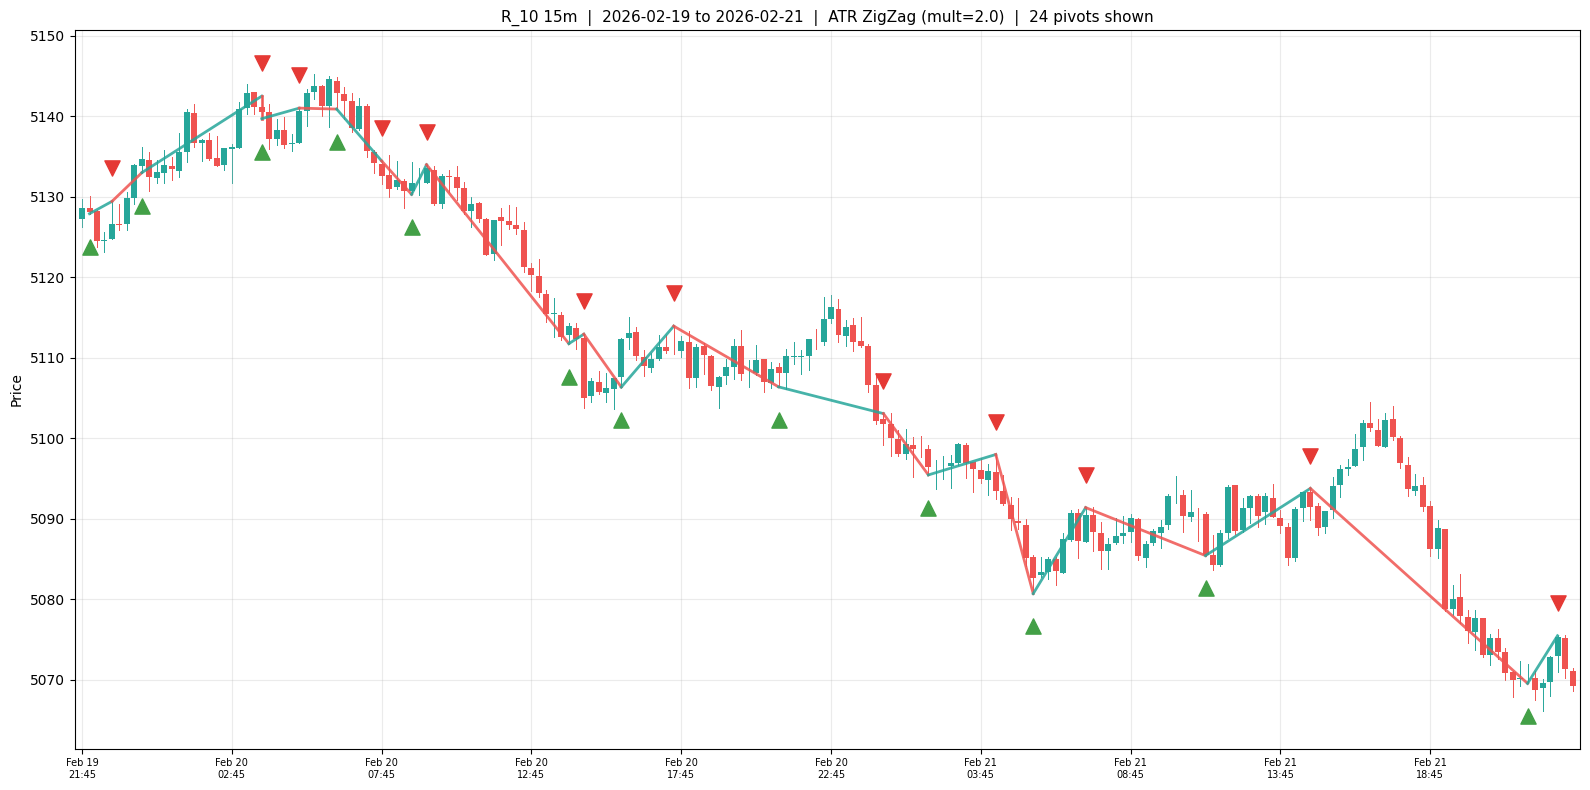

In [4]:
# Cell 3c — ATR ZigZag (state machine, no lookback window)
from src.core.features import detect_swings_atr, _get_atr_mult

atr_mult = _get_atr_mult(TIMEFRAME)
pivots = detect_swings_atr(candles, atr_mult=atr_mult)

print(f"ATR multiplier for {TIMEFRAME}: {atr_mult}")
print(f"Total pivots: {len(pivots)}")
if pivots:
    print(f"First pivot: {pivots[0]}")
    print(f"Last pivot:  {pivots[-1]}")

# --- Chart ---
n_feat = features["meta"]["num_candles"]
feat_offset = len(candles) - n_feat
WINDOW = min(200, n_feat)
disp_offset = n_feat - WINDOW
display_candles = candles[feat_offset:][-WINDOW:]

display_pivots = [
    {**p, "di": p["index"] - disp_offset}
    for p in pivots
    if 0 <= p["index"] - disp_offset < WINDOW
]

fig, ax = plt.subplots(figsize=(16, 8))
UP_COLOR   = "#26a69a"
DOWN_COLOR = "#ef5350"

for i, c in enumerate(display_candles):
    color   = UP_COLOR if c.close >= c.open else DOWN_COLOR
    body_lo = min(c.open, c.close)
    body_hi = max(c.open, c.close)
    body_h  = max(body_hi - body_lo, (c.high - c.low) * 0.01)
    ax.plot([i, i], [c.low, c.high], color=color, linewidth=0.7, zorder=1)
    ax.add_patch(plt.Rectangle(
        (i - 0.4, body_lo), 0.8, body_h,
        facecolor=color, edgecolor=color, linewidth=0, zorder=2))

# Draw zigzag lines connecting consecutive pivots
for j in range(1, len(display_pivots)):
    prev = display_pivots[j-1]
    curr = display_pivots[j]
    prev_price = display_candles[prev["di"]].high if prev["type"] == "SH" \
                 else display_candles[prev["di"]].low
    curr_price = display_candles[curr["di"]].high if curr["type"] == "SH" \
                 else display_candles[curr["di"]].low
    color = "#ef5350" if curr["type"] == "SL" else "#26a69a"
    ax.plot([prev["di"], curr["di"]], [prev_price, curr_price],
            color=color, linewidth=2, zorder=4, alpha=0.85)

# Overlay pivot markers
for p in display_pivots:
    c = display_candles[p["di"]]
    if p["type"] == "SH":
        ax.scatter(p["di"], c.high * 1.0008, marker="v",
                   color="#e53935", s=120, zorder=5)
    else:
        ax.scatter(p["di"], c.low * 0.9992, marker="^",
                   color="#43a047", s=120, zorder=5)

tick_step = max(1, WINDOW // 10)
tick_pos  = list(range(0, len(display_candles), tick_step))
tick_lbl  = [display_candles[i].timestamp.strftime("%b %d\n%H:%M")
             for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=7)
ax.set_xlim(-1, WINDOW)
ax.set_ylabel("Price")
ax.grid(True, alpha=0.25)

d_start = display_candles[0].timestamp.strftime("%Y-%m-%d")
d_end   = display_candles[-1].timestamp.strftime("%Y-%m-%d")
ax.set_title(
    f"{SYMBOL} {TIMEFRAME}  |  {d_start} to {d_end}  |  "
    f"ATR ZigZag (mult={atr_mult})  |  {len(display_pivots)} pivots shown",
    fontsize=11)

plt.tight_layout()
plt.show()


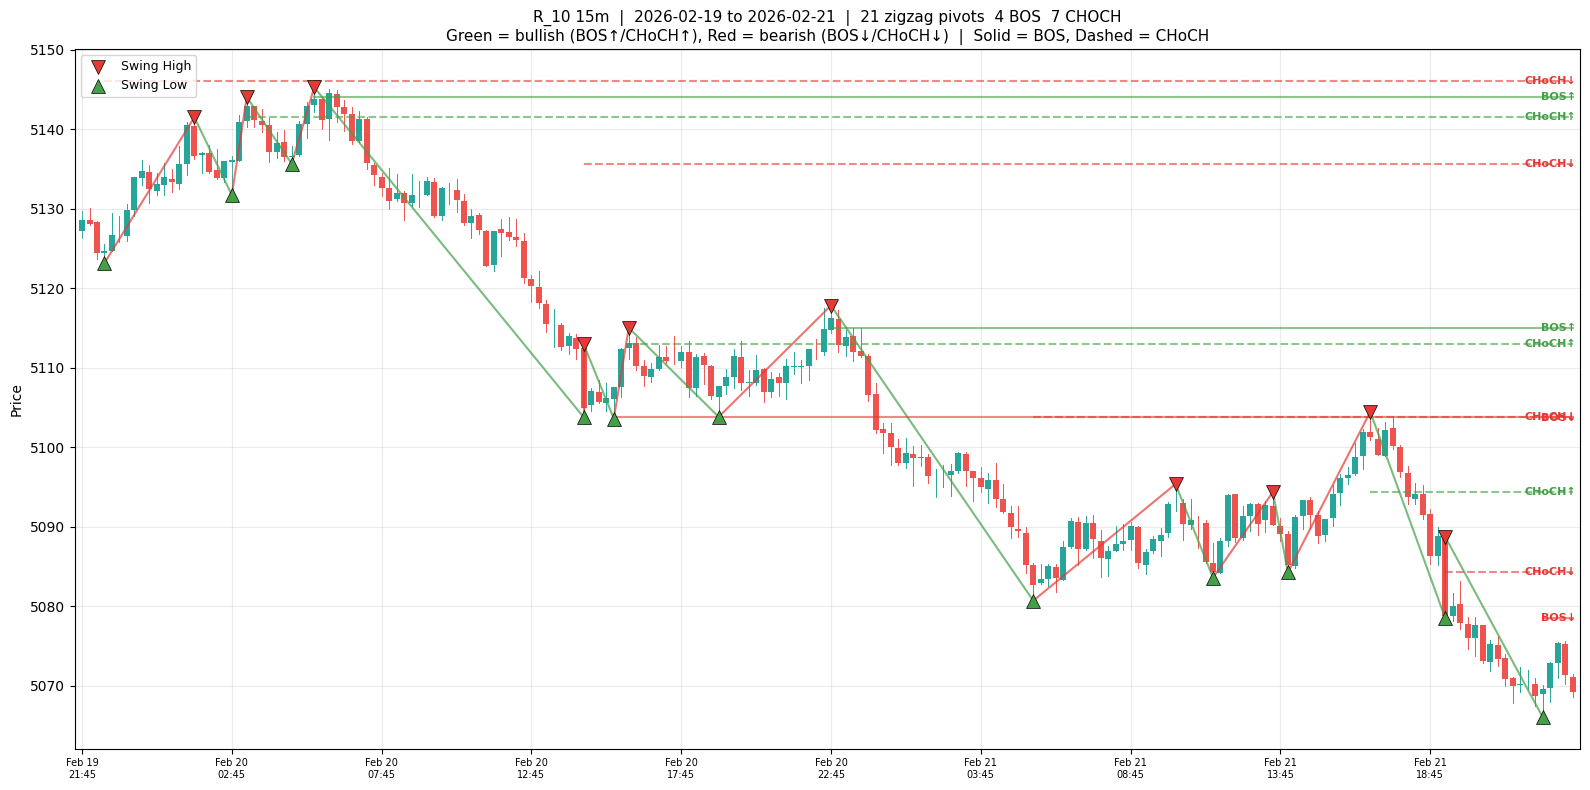


Zigzag summary (lookback=10):
  Zigzag pivots : 21
  BOS events    : 4
  CHOCH events  : 7


In [5]:
# Cell 3b - Candlestick chart with zigzag and BOS/CHOCH overlay

lookback = LOOKBACK_CONFIG.get(TIMEFRAME, 10)
zigzag = compute_zigzag(swings)
events = detect_bos_choch_from_zigzag(zigzag)

n_feat = features["meta"]["num_candles"]
feat_offset = len(candles) - n_feat
WINDOW = min(200, n_feat)
disp_offset = n_feat - WINDOW

display_candles = candles[feat_offset:][-WINDOW:]

# Filter zigzag and events to display window
display_zigzag = [
    {**z, 'di': z['index'] - disp_offset}
    for z in zigzag
    if 0 <= z['index'] - disp_offset < WINDOW
]
display_events = [
    {**e, 'di': e['index'] - disp_offset}
    for e in events
    if 0 <= e['index'] - disp_offset < WINDOW
]

fig, ax = plt.subplots(figsize=(16, 8))

UP_COLOR = '#26a69a'
DOWN_COLOR = '#ef5350'

# Draw candlesticks
for i, c in enumerate(display_candles):
    color = UP_COLOR if c.close >= c.open else DOWN_COLOR
    body_lo = min(c.open, c.close)
    body_hi = max(c.open, c.close)
    body_h = max(body_hi - body_lo, (c.high - c.low) * 0.01)
    ax.plot([i, i], [c.low, c.high], color=color, linewidth=0.7, zorder=1)
    ax.add_patch(Rectangle(
        (i - 0.4, body_lo), 0.8, body_h,
        facecolor=color, edgecolor=color, linewidth=0, zorder=2,
    ))

# Draw zigzag lines connecting pivots
if len(display_zigzag) >= 2:
    for j in range(len(display_zigzag) - 1):
        p1, p2 = display_zigzag[j], display_zigzag[j + 1]
        x1, y1 = p1['di'], p1['price']
        x2, y2 = p2['di'], p2['price']
        line_color = '#43a047' if p1['type'] == 'SH' else '#e53935'
        ax.plot([x1, x2], [y1, y2], color=line_color, linewidth=1.5, alpha=0.7, zorder=3)

# Mark zigzag points
for z in display_zigzag:
    di, price = z['di'], z['price']
    marker = 'v' if z['type'] == 'SH' else '^'
    zcolor = '#e53935' if z['type'] == 'SH' else '#43a047'
    ax.scatter(di, price, marker=marker, color=zcolor, s=100, zorder=5, edgecolors='black', linewidth=0.5)

# Draw BOS/CHOCH events as horizontal lines with labels at right edge
# BOS: solid line (structural continuation)   -- BOS_UP=green, BOS_DOWN=red
# CHOCH: dashed line (trend reversal)         -- CHOCH_UP=green, CHOCH_DOWN=red
for e in display_events:
    di = e['di']
    price = e['price']
    event_type = e['type']

    if event_type == 'BOS_UP':
        ev_color, ev_ls, ev_label = '#43a047', '-', 'BOS\u2191'
    elif event_type == 'BOS_DOWN':
        ev_color, ev_ls, ev_label = '#e53935', '-', 'BOS\u2193'
    elif event_type == 'CHOCH_UP':
        ev_color, ev_ls, ev_label = '#43a047', '--', 'CHoCH\u2191'
    else:  # CHOCH_DOWN
        ev_color, ev_ls, ev_label = '#e53935', '--', 'CHoCH\u2193'

    ax.plot([di, WINDOW - 1], [price, price], color=ev_color, linestyle=ev_ls,
            linewidth=1.5, alpha=0.6, zorder=4)
    ax.text(WINDOW - 0.5, price, ev_label, fontsize=8, ha='right', va='center',
            color=ev_color, fontweight='bold', zorder=4)

tick_step = max(1, WINDOW // 10)
tick_pos = list(range(0, len(display_candles), tick_step))
tick_lbl = [display_candles[i].timestamp.strftime('%b %d\n%H:%M') for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=7)
ax.set_xlim(-1, WINDOW)
ax.set_ylabel('Price')
ax.grid(True, alpha=0.25)

d_start = display_candles[0].timestamp.strftime('%Y-%m-%d')
d_end = display_candles[-1].timestamp.strftime('%Y-%m-%d')
n_bos = len([e for e in display_events if 'BOS' in e['type']])
n_choch = len([e for e in display_events if 'CHOCH' in e['type']])

ax.set_title(
    f"{SYMBOL} {TIMEFRAME}  |  {d_start} to {d_end}  |  "
    f"{len(display_zigzag)} zigzag pivots  {n_bos} BOS  {n_choch} CHOCH\n"
    "Green = bullish (BOS\u2191/CHoCH\u2191), Red = bearish (BOS\u2193/CHoCH\u2193)"
    "  |  Solid = BOS, Dashed = CHoCH",
    fontsize=11,
)

sh_h = ax.scatter([], [], marker='v', color='#e53935', s=100, edgecolors='black', linewidth=0.5, label='Swing High')
sl_h = ax.scatter([], [], marker='^', color='#43a047', s=100, edgecolors='black', linewidth=0.5, label='Swing Low')
ax.legend(handles=[sh_h, sl_h], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nZigzag summary (lookback={lookback}):')
print(f'  Zigzag pivots : {len(display_zigzag)}')
print(f'  BOS events    : {n_bos}')
print(f'  CHOCH events  : {n_choch}')


In [6]:
# Quick multiplier test — run directly in notebook
for mult in [2.0, 2.5, 3.0, 3.5, 4.0]:
    pivots = detect_swings_atr(candles, atr_mult=mult)
    print(f"mult={mult:.1f} → {len(pivots)} pivots")

mult=2.0 → 102 pivots
mult=2.5 → 61 pivots
mult=3.0 → 47 pivots
mult=3.5 → 35 pivots
mult=4.0 → 21 pivots


ATR multiplier for 15m: 2.0
Total pivots: 21
First pivot: {'type': 'SH', 'price': 5322.486, 'index': 7, 'timestamp': datetime.datetime(2026, 2, 11, 15, 30), 'strength': 4.019909072480969}
Last pivot:  {'type': 'SH', 'price': 5104.449, 'index': 972, 'timestamp': datetime.datetime(2026, 2, 21, 16, 45), 'strength': 4.513237452305171}


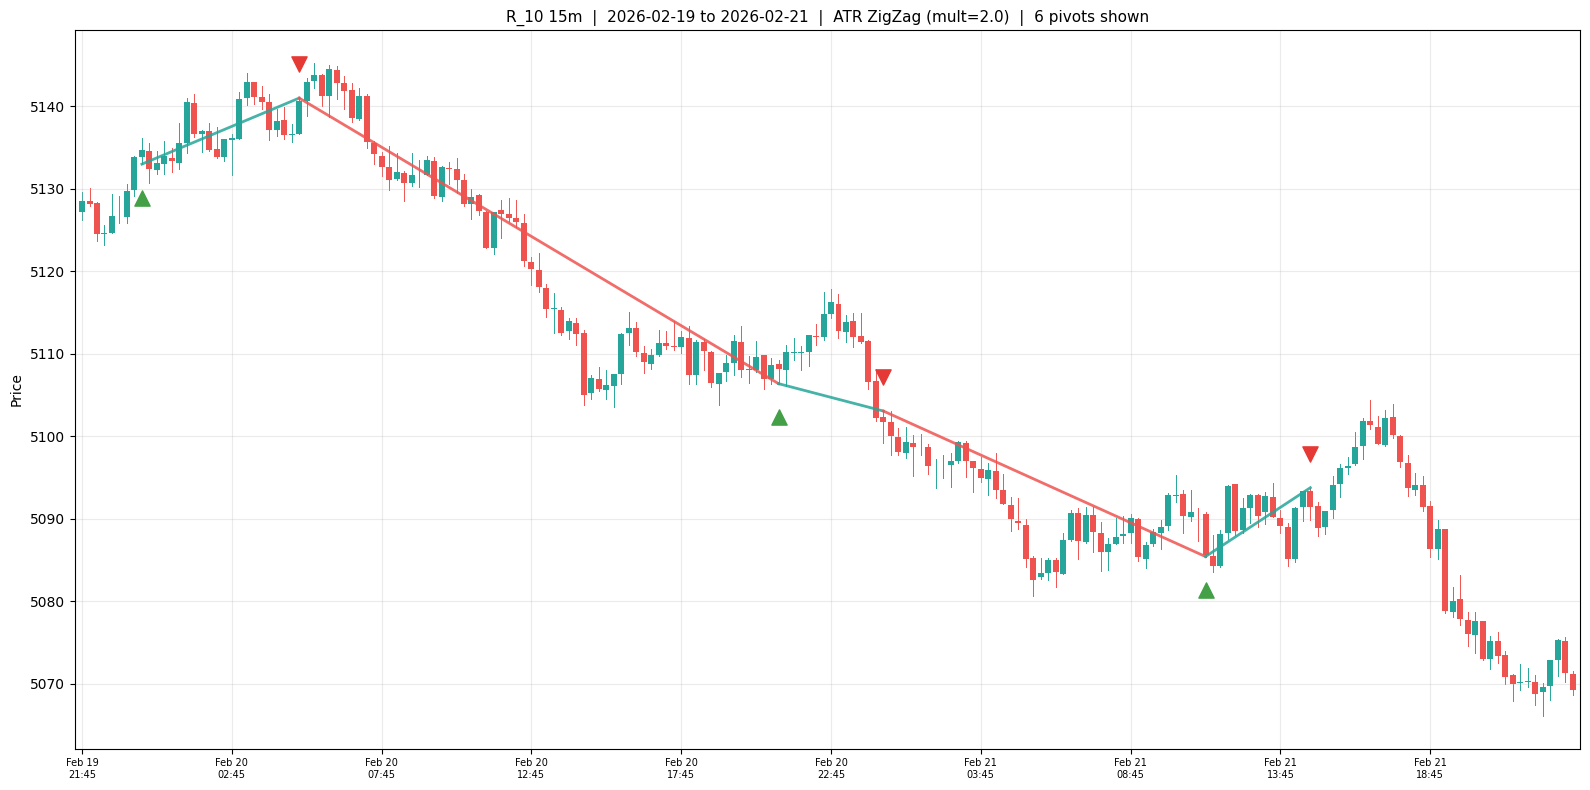

In [7]:
# Cell 3c — ATR ZigZag (state machine, no lookback window)

from src.core.features import detect_swings_atr, _get_atr_mult

atr_mult = _get_atr_mult(TIMEFRAME)

#pivots = detect_swings_atr(candles, atr_mult=atr_mult)
pivots = detect_swings_atr(candles, atr_mult=4.0)

print(f"ATR multiplier for {TIMEFRAME}: {atr_mult}")
print(f"Total pivots: {len(pivots)}")
if pivots:
    print(f"First pivot: {pivots[0]}")
    print(f"Last pivot:  {pivots[-1]}")

# --- Chart ---
n_feat = features["meta"]["num_candles"]
feat_offset = len(candles) - n_feat
WINDOW = min(200, n_feat)
disp_offset = n_feat - WINDOW

display_candles = candles[feat_offset:][-WINDOW:]

display_pivots = [
    {**p, "di": p["index"] - disp_offset}
    for p in pivots
    if 0 <= p["index"] - disp_offset < WINDOW
]

fig, ax = plt.subplots(figsize=(16, 8))

UP_COLOR = "#26a69a"
DOWN_COLOR = "#ef5350"

# Draw candles
for i, c in enumerate(display_candles):
    color = UP_COLOR if c.close >= c.open else DOWN_COLOR
    body_lo = min(c.open, c.close)
    body_hi = max(c.open, c.close)
    body_h = max(body_hi - body_lo, (c.high - c.low) * 0.01)

    ax.plot([i, i], [c.low, c.high], color=color, linewidth=0.7, zorder=1)
    ax.add_patch(
        plt.Rectangle(
            (i - 0.4, body_lo),
            0.8,
            body_h,
            facecolor=color,
            edgecolor=color,
            linewidth=0,
            zorder=2
        )
    )

# Draw zigzag lines connecting consecutive pivots
for j in range(1, len(display_pivots)):
    prev = display_pivots[j - 1]
    curr = display_pivots[j]

    prev_price = (
        display_candles[prev["di"]].high if prev["type"] == "SH"
        else display_candles[prev["di"]].low
    )
    curr_price = (
        display_candles[curr["di"]].high if curr["type"] == "SH"
        else display_candles[curr["di"]].low
    )

    color = "#ef5350" if curr["type"] == "SL" else "#26a69a"

    ax.plot(
        [prev["di"], curr["di"]],
        [prev_price, curr_price],
        color=color,
        linewidth=2,
        zorder=4,
        alpha=0.85
    )

# Overlay pivot markers
for p in display_pivots:
    c = display_candles[p["di"]]
    if p["type"] == "SH":
        ax.scatter(
            p["di"], c.high * 1.0008,
            marker="v", color="#e53935", s=120, zorder=5
        )
    else:
        ax.scatter(
            p["di"], c.low * 0.9992,
            marker="^", color="#43a047", s=120, zorder=5
        )

# X‑axis ticks
tick_step = max(1, WINDOW // 10)
tick_pos = list(range(0, len(display_candles), tick_step))
tick_lbl = [
    display_candles[i].timestamp.strftime("%b %d\n%H:%M")
    for i in tick_pos
]

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=7)
ax.set_xlim(-1, WINDOW)
ax.set_ylabel("Price")
ax.grid(True, alpha=0.25)

# Title
d_start = display_candles[0].timestamp.strftime("%Y-%m-%d")
d_end = display_candles[-1].timestamp.strftime("%Y-%m-%d")

ax.set_title(
    f"{SYMBOL} {TIMEFRAME}  |  {d_start} to {d_end}  |  "
    f"ATR ZigZag (mult={atr_mult})  |  {len(display_pivots)} pivots shown",
    fontsize=11
)

plt.tight_layout()
plt.show()


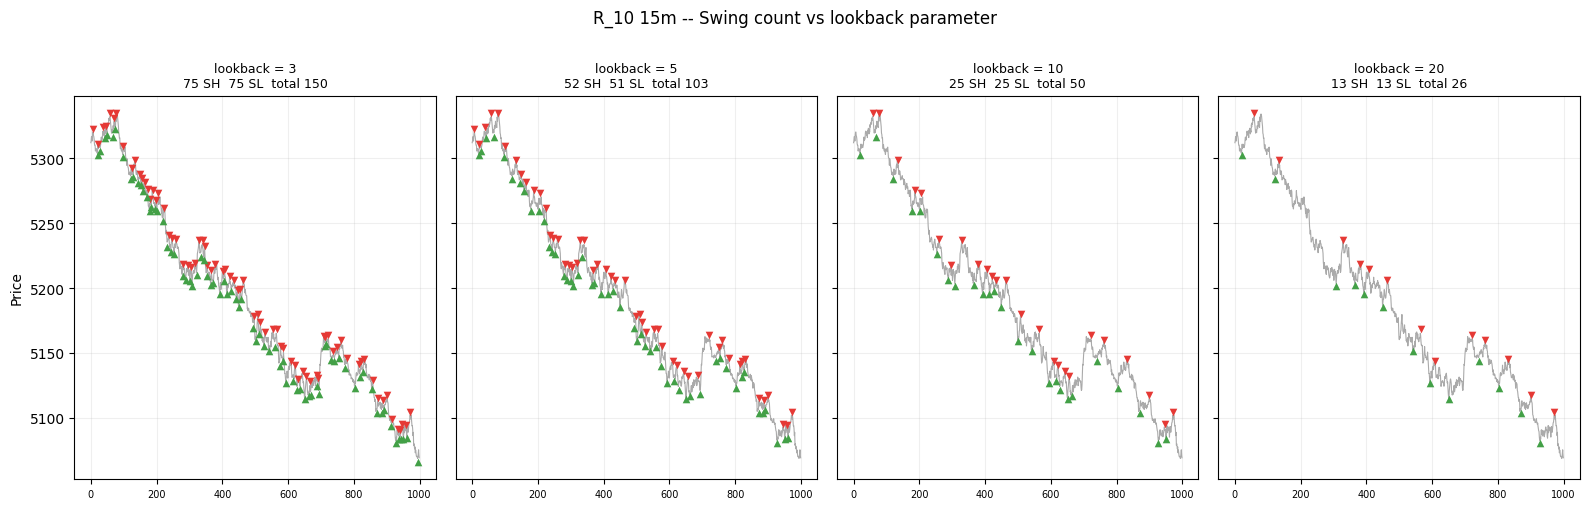

  lookback    total     SH     SL
--------------------------------
         3      150     75     75
         5      103     52     51
        10       50     25     25
        20       26     13     13


In [8]:
# Cell 4 - Multi-lookback comparison
from src.core.features import detect_swings

highs_arr = [c.high  for c in candles]
lows_arr  = [c.low   for c in candles]
close_arr = [c.close for c in candles]

LOOKBACKS = [3, 5, 10, 20]

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle(
    f"{SYMBOL} {TIMEFRAME} -- Swing count vs lookback parameter",
    fontsize=12, y=1.01,
)

for ax, lb in zip(axes, LOOKBACKS):
    sw = detect_swings(highs_arr, lows_arr, lookback=lb)
    sh = [s for s in sw if s['type'] == 'SH']
    sl = [s for s in sw if s['type'] == 'SL']

    ax.plot(close_arr, color='#aaa', linewidth=0.8)

    for s in sh:
        ax.scatter(s['index'], highs_arr[s['index']],
                   marker='v', color='#e53935', s=30, zorder=4, linewidths=0)
    for s in sl:
        ax.scatter(s['index'], lows_arr[s['index']],
                   marker='^', color='#43a047', s=30, zorder=4, linewidths=0)

    ax.set_title(
        f"lookback = {lb}\n{len(sh)} SH  {len(sl)} SL  total {len(sw)}",
        fontsize=9,
    )
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Price')
plt.tight_layout()
plt.show()

# Summary table
col_lb    = 'lookback'
col_total = 'total'
col_sh    = 'SH'
col_sl    = 'SL'
print(f"{col_lb:>10}  {col_total:>7}  {col_sh:>5}  {col_sl:>5}")
print('-' * 32)
for lb in LOOKBACKS:
    sw   = detect_swings(highs_arr, lows_arr, lookback=lb)
    n_sh = sum(1 for s in sw if s['type'] == 'SH')
    n_sl = sum(1 for s in sw if s['type'] == 'SL')
    print(f"{lb:>10}  {len(sw):>7}  {n_sh:>5}  {n_sl:>5}")


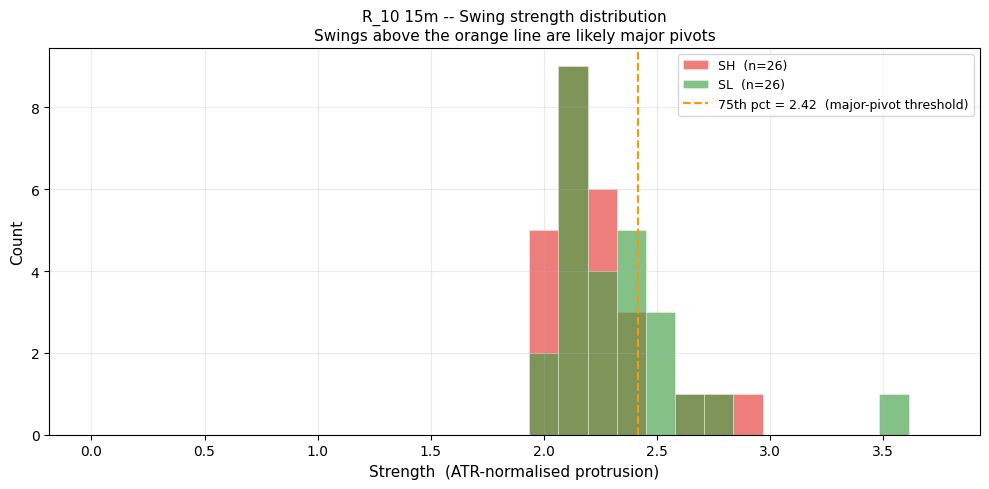


Strength stats  (52 swings total):
  min    = 2.006
  25th   = 2.103
  median = 2.197
  75th   = 2.416
  max    = 3.564

Major pivots (strength >= 75th pct): 13
  [SH] idx=   9  price= 5179.8310  strength=2.695  ts=2026-02-16 21:00:00
  [SL] idx=  93  price= 5126.5520  strength=2.429  ts=2026-02-17 18:00:00
  [SL] idx= 128  price= 5121.6280  strength=2.817  ts=2026-02-18 02:45:00
  [SH] idx= 156  price= 5132.4390  strength=2.768  ts=2026-02-18 09:45:00
  [SL] idx= 169  price= 5117.7190  strength=2.430  ts=2026-02-18 13:00:00


In [9]:
# Cell 5 - Swing strength distribution
if not swings:
    print('No swings detected -- cannot plot strength distribution.')
else:
    strengths_sh = [s['strength'] for s in swings if s['type'] == 'SH']
    strengths_sl = [s['strength'] for s in swings if s['type'] == 'SL']
    all_str      = strengths_sh + strengths_sl

    hi_edge = max(all_str) * 1.05 if all_str else 1.0
    bins    = np.linspace(0, hi_edge, 30)
    p75     = np.percentile(all_str, 75)

    fig, ax = plt.subplots(figsize=(10, 5))

    if strengths_sh:
        ax.hist(strengths_sh, bins=bins, alpha=0.65, color='#e53935',
                label=f'SH  (n={len(strengths_sh)})', edgecolor='white', linewidth=0.4)
    if strengths_sl:
        ax.hist(strengths_sl, bins=bins, alpha=0.65, color='#43a047',
                label=f'SL  (n={len(strengths_sl)})', edgecolor='white', linewidth=0.4)

    ax.axvline(p75, color='#ff9800', linestyle='--', linewidth=1.5,
               label=f'75th pct = {p75:.2f}  (major-pivot threshold)')

    ax.set_xlabel('Strength  (ATR-normalised protrusion)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(
        f"{SYMBOL} {TIMEFRAME} -- Swing strength distribution\n"
        "Swings above the orange line are likely major pivots",
        fontsize=11,
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f'\nStrength stats  ({len(all_str)} swings total):')
    print(f'  min    = {min(all_str):.3f}')
    print(f'  25th   = {np.percentile(all_str, 25):.3f}')
    print(f'  median = {np.percentile(all_str, 50):.3f}')
    print(f'  75th   = {p75:.3f}')
    print(f'  max    = {max(all_str):.3f}')

    major = [s for s in swings if s['strength'] >= p75]
    print(f'\nMajor pivots (strength >= 75th pct): {len(major)}')
    for s in major[:5]:
        ts = str(s.get('timestamp', ''))[:19]
        print(
            f"  [{s['type']}] idx={s['index']:>4}  "
            f"price={s['price']:>10.4f}  "
            f"strength={s['strength']:.3f}  ts={ts}"
        )


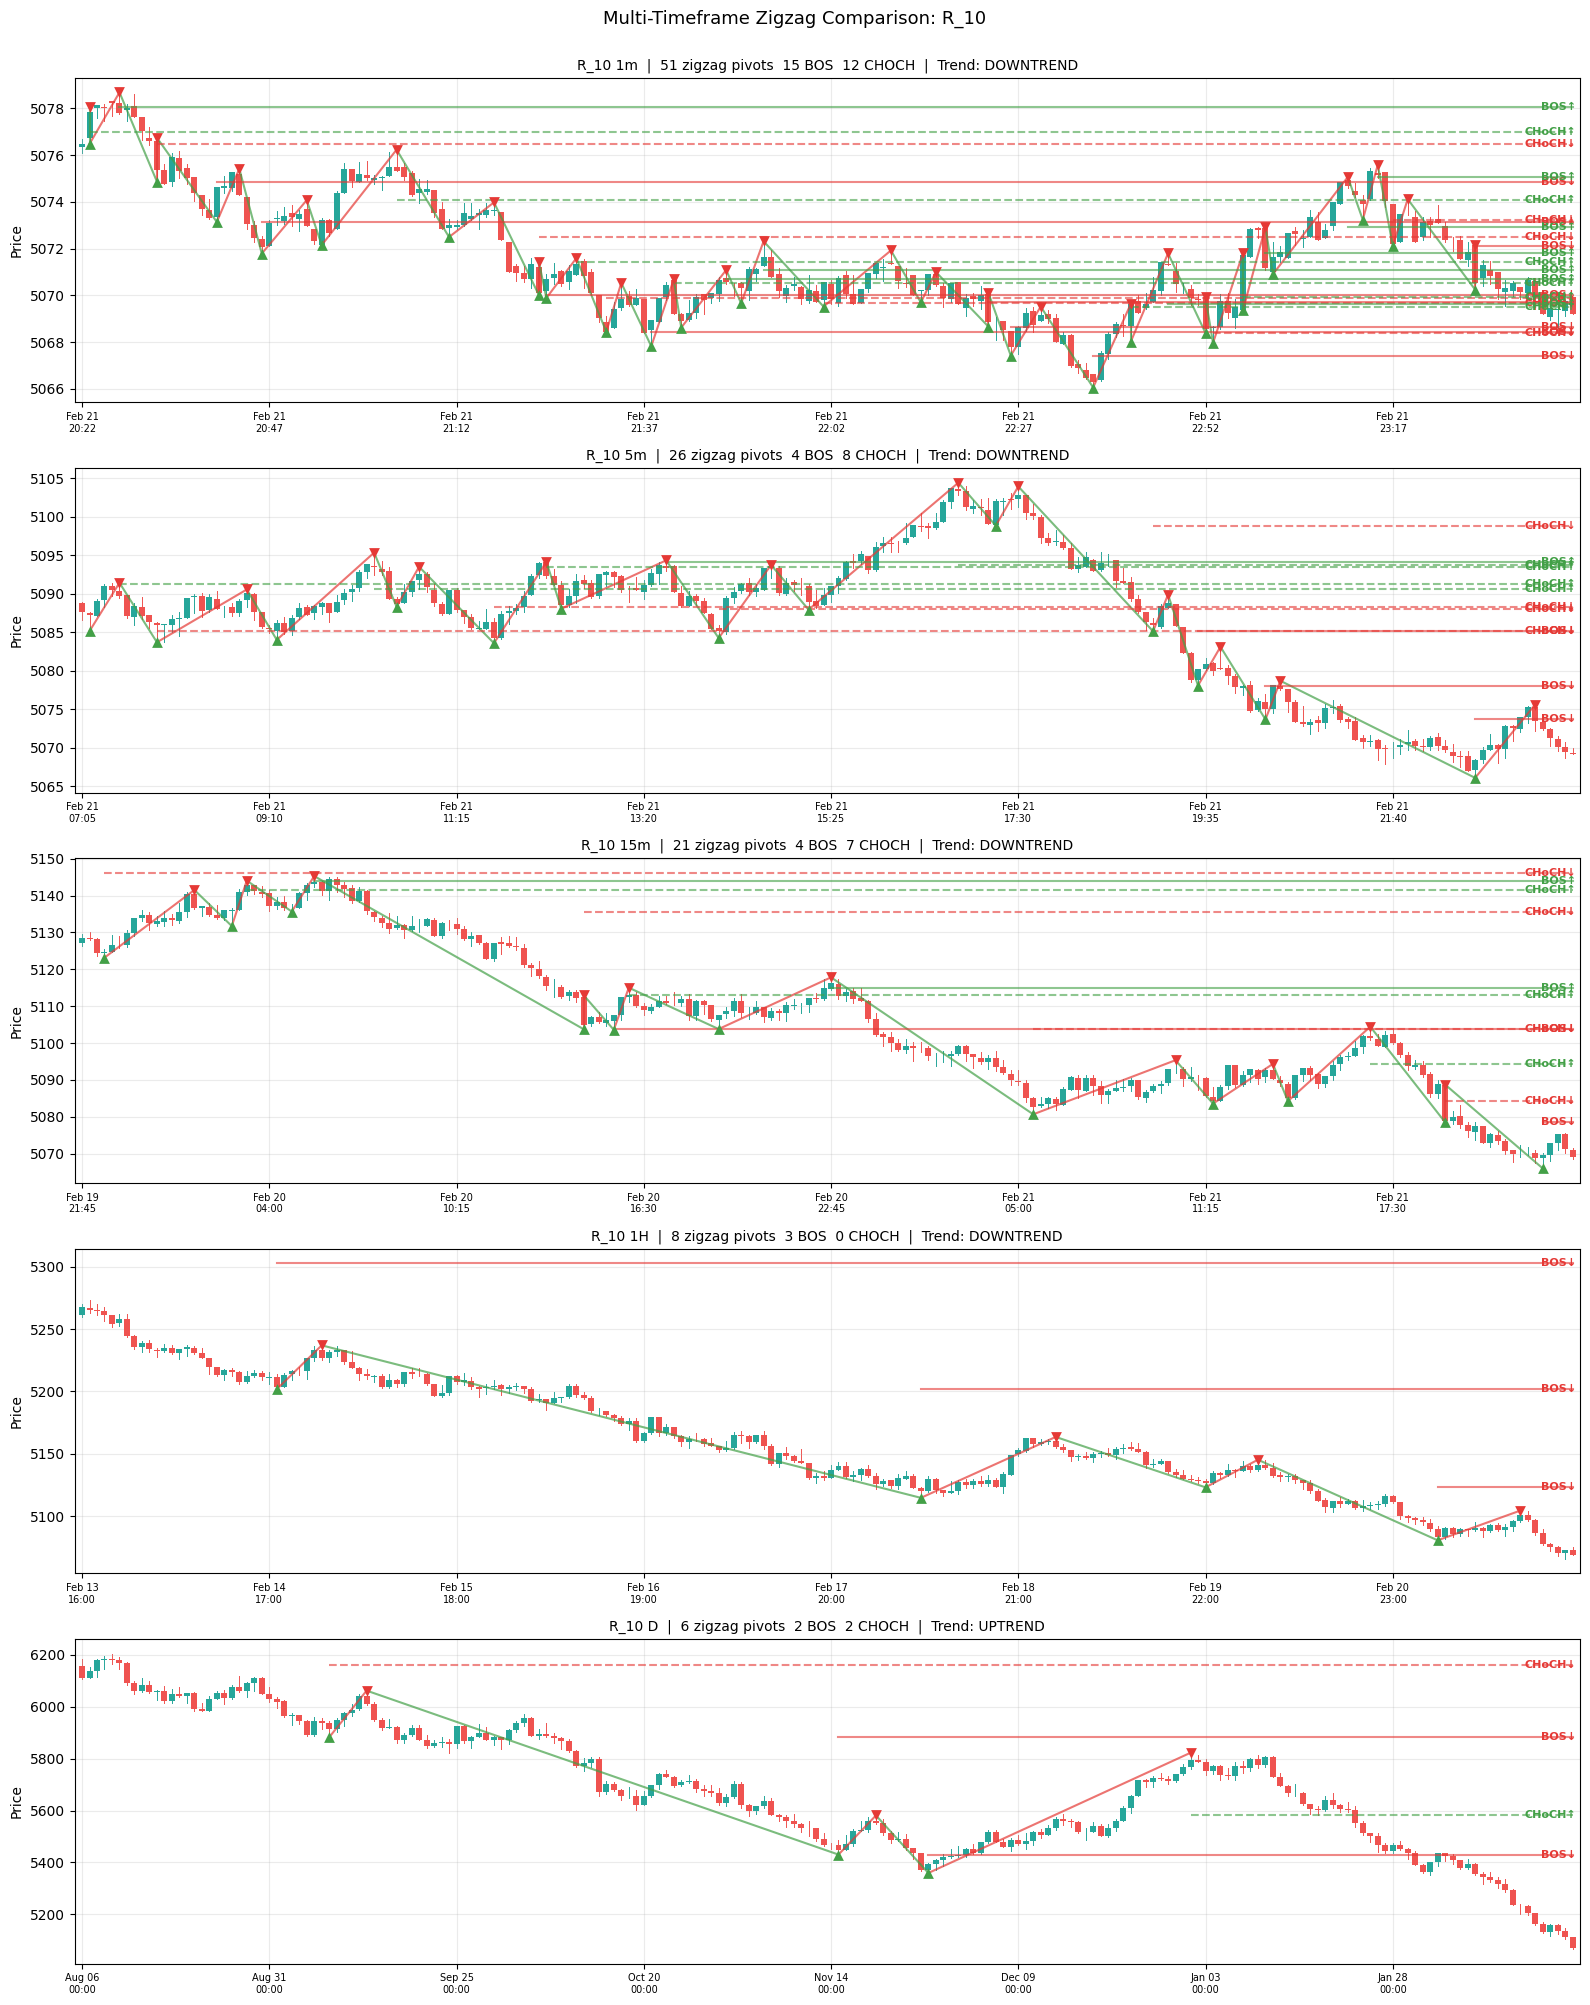


Loaded 5 timeframes for R_10:
  1m: 1000 candles
  5m: 1000 candles
  15m: 1000 candles
  1H: 1000 candles
  D: 366 candles


In [10]:
# Cell 6 - Multi-timeframe view with zigzag overlay
import glob
from pathlib import Path as PathlibPath

# Load all available CSVs from data/processed/
processed_dir = ROOT / 'data' / 'processed'
csv_paths = sorted(processed_dir.glob('*.csv')) if processed_dir.exists() else []

if csv_paths:
    # Group by symbol and timeframe
    timeframe_data = {}
    for csv_path in csv_paths:
        parts = csv_path.stem.rsplit('_', 1)
        if len(parts) == 2:
            symbol, tf = parts
            if symbol not in timeframe_data:
                timeframe_data[symbol] = {}
            timeframe_data[symbol][tf] = csv_path

    # Pick the first symbol (or current if available)
    symbol_to_plot = SYMBOL if SYMBOL in timeframe_data else (list(timeframe_data.keys())[0] if timeframe_data else None)

    if symbol_to_plot and symbol_to_plot in timeframe_data:
        tf_dict = timeframe_data[symbol_to_plot]
        timeframes_list = sorted(tf_dict.keys(), key=lambda x: (['1m', '5m', '15m', '1H', '4H', '1D', 'D'].index(x) if x in ['1m', '5m', '15m', '1H', '4H', '1D', 'D'] else 999))

        n_tf = len(timeframes_list)
        fig, axes = plt.subplots(n_tf, 1, figsize=(16, 4 * n_tf), sharex=False)
        if n_tf == 1:
            axes = [axes]

        for idx, (tf, csv_path) in enumerate([(tf, tf_dict[tf]) for tf in timeframes_list]):
            tf_candles = load_ohlc_from_csv(csv_path)
            tf_features = compute_price_features(tf_candles, timeframe=tf)
            tf_zigzag = compute_zigzag(tf_features['structure_map']['swings'])
            tf_events = detect_bos_choch_from_zigzag(tf_zigzag)

            # Use features["meta"]["num_candles"] for correct coordinate space
            n_feat = tf_features["meta"]["num_candles"]
            feat_offset = len(tf_candles) - n_feat
            WINDOW_MTF = min(200, n_feat)
            disp_offset = n_feat - WINDOW_MTF

            display_tf_candles = tf_candles[feat_offset:][-WINDOW_MTF:]
            display_tf_zigzag = [
                {**z, 'di': z['index'] - disp_offset}
                for z in tf_zigzag
                if 0 <= z['index'] - disp_offset < WINDOW_MTF
            ]
            display_tf_events = [
                {**e, 'di': e['index'] - disp_offset}
                for e in tf_events
                if 0 <= e['index'] - disp_offset < WINDOW_MTF
            ]

            ax = axes[idx]

            # Draw candlesticks
            UP_COLOR_MTF = '#26a69a'
            DOWN_COLOR_MTF = '#ef5350'
            for i, c in enumerate(display_tf_candles):
                color = UP_COLOR_MTF if c.close >= c.open else DOWN_COLOR_MTF
                body_lo = min(c.open, c.close)
                body_hi = max(c.open, c.close)
                body_h = max(body_hi - body_lo, (c.high - c.low) * 0.01)
                ax.plot([i, i], [c.low, c.high], color=color, linewidth=0.7, zorder=1)
                ax.add_patch(Rectangle(
                    (i - 0.4, body_lo), 0.8, body_h,
                    facecolor=color, edgecolor=color, linewidth=0, zorder=2,
                ))

            # Draw zigzag lines
            if len(display_tf_zigzag) >= 2:
                for j in range(len(display_tf_zigzag) - 1):
                    p1, p2 = display_tf_zigzag[j], display_tf_zigzag[j + 1]
                    x1, y1 = p1['di'], p1['price']
                    x2, y2 = p2['di'], p2['price']
                    line_color = '#43a047' if p1['type'] == 'SH' else '#e53935'
                    ax.plot([x1, x2], [y1, y2], color=line_color, linewidth=1.5, alpha=0.7, zorder=3)

            # Mark zigzag points
            for z in display_tf_zigzag:
                di, price = z['di'], z['price']
                marker = 'v' if z['type'] == 'SH' else '^'
                zcolor = '#e53935' if z['type'] == 'SH' else '#43a047'
                ax.scatter(di, price, marker=marker, color=zcolor, s=60, zorder=5, linewidths=0)

            # Draw BOS/CHOCH events as horizontal lines with labels at right edge
            # BOS: solid line (continuation) -- BOS_UP=green, BOS_DOWN=red
            # CHOCH: dashed line (reversal)  -- CHOCH_UP=green, CHOCH_DOWN=red
            for e in display_tf_events:
                di = e['di']
                price = e['price']
                event_type = e['type']

                if event_type == 'BOS_UP':
                    ev_color, ev_ls, ev_label = '#43a047', '-', 'BOS\u2191'
                elif event_type == 'BOS_DOWN':
                    ev_color, ev_ls, ev_label = '#e53935', '-', 'BOS\u2193'
                elif event_type == 'CHOCH_UP':
                    ev_color, ev_ls, ev_label = '#43a047', '--', 'CHoCH\u2191'
                else:  # CHOCH_DOWN
                    ev_color, ev_ls, ev_label = '#e53935', '--', 'CHoCH\u2193'

                ax.plot([di, WINDOW_MTF - 1], [price, price], color=ev_color, linestyle=ev_ls,
                        linewidth=1.5, alpha=0.6, zorder=4)
                ax.text(WINDOW_MTF - 0.5, price, ev_label, fontsize=8, ha='right', va='center',
                        color=ev_color, fontweight='bold', zorder=4)

            # Determine trend from last 3 zigzag points
            trend = 'Unknown'
            if len(display_tf_zigzag) >= 3:
                last3 = display_tf_zigzag[-3:]
                if last3[-1]['price'] > last3[0]['price']:
                    trend = 'UPTREND'
                elif last3[-1]['price'] < last3[0]['price']:
                    trend = 'DOWNTREND'
                else:
                    trend = 'RANGING'

            tick_step = max(1, len(display_tf_candles) // 8)
            tick_pos = list(range(0, len(display_tf_candles), tick_step))
            tick_lbl = [display_tf_candles[i].timestamp.strftime('%b %d\n%H:%M') for i in tick_pos]
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_lbl, fontsize=7)

            ax.set_ylabel('Price')
            ax.grid(True, alpha=0.25)

            n_bos = len([e for e in display_tf_events if 'BOS' in e['type']])
            n_choch = len([e for e in display_tf_events if 'CHOCH' in e['type']])

            ax.set_title(
                f'{symbol_to_plot} {tf}  |  {len(display_tf_zigzag)} zigzag pivots'
                f'  {n_bos} BOS  {n_choch} CHOCH  |  Trend: {trend}',
                fontsize=10,
            )
            ax.set_xlim(-1, WINDOW_MTF)

        fig.suptitle(f'Multi-Timeframe Zigzag Comparison: {symbol_to_plot}', fontsize=13, y=1.00)
        plt.tight_layout()
        plt.show()

        print(f'\nLoaded {n_tf} timeframes for {symbol_to_plot}:')
        for tf in timeframes_list:
            tf_candles = load_ohlc_from_csv(tf_dict[tf])
            print(f'  {tf}: {len(tf_candles)} candles')
    else:
        print('No symbol data found in data/processed/')
else:
    print('No CSV files found in data/processed/ -- multi-timeframe view requires real data')
